In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import re

from plotly.tools import mpl_to_plotly
import plotly.io as pio
from tracker.iou import *

In [3]:
def load_subj(subj):
    """
    Load a subject's data from folder. The subject's data is stored in a JSON file, a csv file, and a txt file
    """
    
    p2json = os.path.join("data",subj.lower(), "trackers.json")
    p2centroids = os.path.join("data",subj.lower(), "centroids.txt")
    with open(p2json, 'r') as f:
        subj_trackers = json.load(f)
    
    with open(p2centroids, 'r') as f:
        subj_centroids = np.array(eval(f.readline()))
    subj_long_dfs = pd.read_csv(os.path.join("data", subj.lower(), "long_dfs.csv"), index_col="frame") 
    subj_long_dfs.index = subj_long_dfs.index.astype(int)

    subj_trackers = {int(k): v for k, v in subj_trackers.items()}

    return subj_trackers, subj_long_dfs, subj_centroids

In [4]:
def generate_merge_summarize(trackers, dfs):
    tmp_summarize = generate_summarize(trackers)
    tmp_trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
    for i in range(len(tmp_summarize)):
        tmp_df = tmp_summarize.iloc[i]
        tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, dfs, trackers)
        tmp_trackers_type_df.loc[len(tmp_trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
        
    tmp_merged_summarize = pd.merge(tmp_summarize, tmp_trackers_type_df, on="num")
    return tmp_merged_summarize

In [5]:
def trackers2fine(trackers, dfs):
    tmp_merge_summarize = generate_merge_summarize(trackers, dfs)
    split_from_df = pd.concat([split_from(i, tmp_merge_summarize) for i in range(len(tmp_merge_summarize))], ignore_index=True)
    split_from_df = split_from_df.loc[split_from_df.is_split == True]
    tmp_all_num = []
    for i in range(len(split_from_df)):
        nex_num = split_from_df.iloc[i].nex_num
        diff = split_from_df.iloc[i]['difference']
        nex_start = split_from_df.iloc[i]["nex_start"]
        this_num = split_from_df.iloc[i].this_num
        tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])
        for i,j in zip(nex_start, diff):
            if j != 0:
                tmp_df.loc[len(tmp_df)] = [this_num, i]
        tmp_all_num.append(tmp_df)
    critical_split_df = pd.concat(tmp_all_num, ignore_index=True)
    tmp_new_trackers = {}
    ini_indx = 0
    for i in range(len(trackers)):
        if i not in critical_split_df.tracker_num.values:
            tmp_new_trackers[ini_indx] = trackers[i]
            ini_indx += 1
        else:
            split_result = split_trackers(i, critical_split_df, trackers)
            for j in split_result:
                tmp_new_trackers[ini_indx] = j
                ini_indx += 1

    tmp_new_summarize = generate_merge_summarize(tmp_new_trackers, dfs)
        
    merge_to_df = pd.concat([merge_to(i, tmp_new_summarize) for i in range(len(tmp_new_summarize))], ignore_index=True)
    merge_to_df = merge_to_df.loc[merge_to_df.is_merge == True]
    tmp_all_num = []
    for i in range(len(merge_to_df)):
        diff = merge_to_df.iloc[i]['difference']
        nex_start = merge_to_df.iloc[i]["nex_end"]
        this_num = merge_to_df.iloc[i].this_num

        tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

        for i,j in zip(nex_start, diff):
            if j != 0:
                tmp_df.loc[len(tmp_df)] = [this_num, i]
        tmp_all_num.append(tmp_df)
        # print(tmp_df)
    critical_merge_df = pd.concat(tmp_all_num, ignore_index=True)
    critical_merge_df.split_frame += 1
    tmp_new_trackers_2 = {}
    ini_indx = 0
    for i in range(len(tmp_new_trackers)):
        if i not in critical_merge_df.tracker_num.values:
            tmp_new_trackers_2[ini_indx] = tmp_new_trackers[(i)]
            ini_indx += 1
        else:
            split_result = split_trackers(i, critical_merge_df, tmp_new_trackers)
            for j in split_result:
                tmp_new_trackers_2[ini_indx] = j
                ini_indx += 1
    # new_summarize_2 = generate_summarize(new_trackers_2)

    tmp_new_summarize2 = generate_merge_summarize(tmp_new_trackers_2, dfs)

    return tmp_new_trackers_2, tmp_new_summarize2

In [6]:
def find_worms(ini_indx,summarize, banned_list = np.array([])):
    worms = []
    for i in range(len(ini_indx)):
        tmp_worm, banned_list = simple_find_nex(ini_indx[i], summarize, banned_list)
        if new_summarize.loc[ini_indx[i]].start_frame > 300:
            tmp_worm_prev, banned_list = simple_find_prev(ini_indx[i], summarize, banned_list)
            tmp_worm = np.concatenate((tmp_worm_prev[:-1], tmp_worm))
        worms.append(tmp_worm)
    return worms

        

In [ ]:
def diagnosis_worms(worms, summarize, centroid, dfs):
    """
    Diagnosis the worms
    """
    new_worms = []
    for i in range(len(worms)):
        tmp_worm = np.array([k for k in worms[i] if k != -1])
        if summarize.loc[tmp_worm[0]].start_frame > 300:
            print("worm %d start frame > 300" % i)
            continue
        if summarize.loc[tmp_worm[-1]].end_frame < np.max(long_dfs.index):
            if np.linalg.norm(summarize.loc[tmp_worm[-1]].end_centroids - centroid) < 850:
                print("worm %d end frame < max frame" % i)
                continue
        
        new_worms.append(tmp_worm)
    return new_worms
                

In [7]:
all_folders_name = os.listdir("data")
def return_folder_name(date):
    """
    Return the folder name of the data
    """
    return [i for i in all_folders_name if date in i]

In [8]:
return_folder_name("3.17")

['n2_naive5_3.17',
 'n2_trained3_3.17',
 'n2_trained2_3.17',
 'n2_naive4_3.17',
 'n2_trained9_3.17',
 'n2_trained8_3.17',
 'n2_trained7_3.17',
 'n2_trained1_3.17',
 'n2_naive6_3.17']

<Axes: xlabel='frame'>

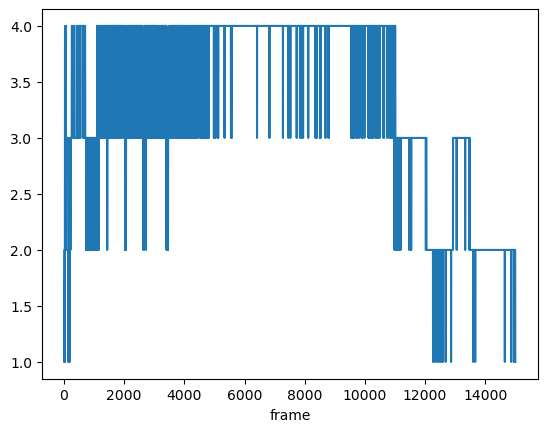

In [173]:
all_trackers, long_dfs, centroid = load_subj( return_folder_name("3.14")[2])
new_trackers, new_summarize = trackers2fine(all_trackers, long_dfs)

long_dfs.groupby('frame').size().plot()

In [174]:
all_ini = find_initial(long_dfs, 4, new_summarize)
ini_indx = all_ini.sort_values(by='start_frame').num.values
print(len(ini_indx))

4


In [175]:
worms = find_worms(ini_indx, new_summarize)
new_worms = diagnosis_worms(worms, new_summarize, centroid, long_dfs)

$[134] all path banned
$[103] all path banned
worm 1 start frame > 300
worm 2 end frame < max frame
worm 3 start frame > 300


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:423: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:423: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [176]:
new_worms

[array([  0,   3,  10,  46,  49,  68,  77,  78,  80, 106, 154])]

In [128]:
new_summarize.loc[new_worms[1][-1]]

num                                                     60
start_frame                                           3252
end_frame                                             5744
durations                                             2492
start_bbox                     [1457.0, 617.0, 17.0, 12.0]
end_bbox                        [1109.0, 340.0, 6.0, 11.0]
start_centroids    [1464.3859649122808, 623.4649122807018]
end_centroids      [1111.7460317460316, 344.6190476190476]
left_type                                            split
right_type                                       disappear
left_prev                                   ([59], [3251])
right_next                                        ([], [])
Name: 60, dtype: object

In [138]:
np.linalg.norm(new_summarize.loc[new_worms[6][-1]].end_centroids - centroid)

920.582889890979

In [ ]:
for i in worms:
    print(i)

$[12] all path banned
[11 12 16 19]
[17 18 59 42 43 63]
[10 33 48]
[37 39 50]
[15 18 59 60 72 80 88 91 93 99]
[30 31 45 51 52 54 56 57 58 67 68 73 76 77 82]
[29 31 34 43 44 51 53 54 55 57 66 67 70]
[ 9 -1]


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [142]:

worms

[array([11, -1]),
 array([17, 18, 59, -1]),
 array([10, -1]),
 array([37, -1]),
 array([15, 18, 59, -1]),
 array([30, 31, -1]),
 array([29, 31, -1]),
 array([ 9, -1])]

In [150]:
new_summarize.loc[[worms[1][-3]]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
91,91,12766,13600,834,"[1823.0, 874.0, 6.0, 10.0]","[1990.0, 715.0, 10.0, 12.0]","[1826.030303030303, 877.6969696969696]","[1993.0114942528733, 719.8563218390805]",appear,disappear,"([], [])","([], [])"


In [149]:
banned_list = np.array([])

worms = []
for i in range(len(ini_indx)):
    tmp_worm, banned_list = simple_find_nex(ini_indx[i], new_summarize, banned_list)
    if new_summarize.loc[ini_indx[i]].start_frame > 300:
        tmp_worm_prev, banned_list = simple_find_prev(ini_indx[i], new_summarize, banned_list)
        tmp_worm = np.concatenate((tmp_worm_prev[:-1], tmp_worm))
    worms.append(tmp_worm)


$[12] all path banned


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [168]:
for i in worms:
    print(i)

[11 12 16 19]
[17 18 59 60 72 80 88 91 93 99]
[10 33 48]
[37 39 50]
[15 18 59 42 43 44 51 53 54 56 57 58 67 70]
[30 31 34 43 63]
[29 31 45 51 52 54 55 57 66 67 68 73 76 77 82]
[ 9 -1]


In [169]:
for j,i in enumerate(worms):
    if i[0] == -1:
        print("worms{} has bad start".format(j+1))
    elif i[-1] == -1:
        print("worms{} has bad end".format(j+1))

worms8 has bad end


In [178]:
find_worms(ini_indx, new_summarize)

$[12] all path banned


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

[array([11, 12, 16, 19]),
 array([17, 18, 59, 42, 43, 44, 51, 53, 54, 55, 57, 58, 67, 68, 73, 76, 77,
        82]),
 array([10, 33, 48]),
 array([37, 39, 50]),
 array([15, 18, 59, 60, 72, 80, 88, 91, 93, 99]),
 array([30, 31, 34, 43, 63]),
 array([29, 31, 45, 51, 52, 54, 56, 57, 66, 67, 70]),
 array([ 9, -1])]

In [ ]:
banned_list = np.array([])
for i in range(len(all_ini)):
    exec("worm{}, banned_list = simple_find_nex(ini_indx[{}], new_summarize,  banned_list)".format(i+1, i))
    if new_summarize.loc[ini_indx[i]].start_frame <= 300:
        continue
    else:
        exec("worm_prev{}, banned_list = simple_find_prev(ini_indx[{}], new_summarize,  banned_list)".format(i+1, i))
        exec("worm{} = np.concatenate((worm_prev{}[:-1], worm{}))".format(i+1, i+1, i+1))

$[12] all path banned


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [ ]:
worm1[-1]

array([11, 12, 16, 19])

In [111]:
new_summarize.loc[[worm3[1]]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
33,33,1237,5488,4251,"[1766.0, 1107.0, 10.0, 7.0]","[1005.0, 1620.0, 13.0, 8.0]","[1771.0666666666666, 1110.5666666666666]","[1010.9230769230768, 1623.423076923077]",appear,disappear,"([], [])","([], [])"


In [124]:
worm8[-1]

-1

In [130]:
new_summarize.loc[[worm7[-1]]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
70,70,8780,9803,1023,"[1515.0, 1833.0, 7.0, 20.0]","[1266.0, 1835.0, 8.0, 8.0]","[1518.0633608815426, 1842.732782369146]","[1268.65873015873, 1838.063492063492]",split,disappear,"([67], [8779])","([], [])"


In [127]:
np.linalg.norm(np.array(new_summarize.loc[worm7[-1]].end_centroids) - centroid)

920.716151486145

In [84]:
new_summarize.loc[worm3]

KeyError: '[-1] not in index'

In [34]:
for j in range(1,11):
    print("worm{}".format(j),eval("worm{}".format(j)))

worm1 [147]
worm2 [ 95  96 104 105 106 128 129 150 151]
worm3 [  0   6   9  10  11  56  57  58  59  60  64  66  68  70  80  96  97 101
 103 105 112 121 122 134 123 136 137 142 143 156 158]
worm4 [ -1  12  23  16  42  37  39  47  48  44  50  51  53  54  62  69  72  73
  74  76  84  85  86  83  89  90 126 109 110 107 115 116 117 118 120 131
 132 141 142 155]
worm5 [ -1   4  41  42  43  52  59  61  65  66  67  70  78  79 108 117 119 120
 149 150 153]
worm6 [22 23 24 25 26 27 15 29 38 39 -1]
worm7 [ -1  20  31  46  53  55  63  69  71  73  75  76  81  85  86  87  91  93
  94  99 100 101 114 115 133 134 135 136 130 132 154]
worm8 [ 13  25  14  27  28  29  30  31  32 113 124 152]
worm9 [ -1  17  18  19  34  35  36  45  57  77  79 125 126 127 128 148]
worm10 [ -1   8  10  33  34  21  36  82  86  87  88  89  92  93  98  99 102 110
 111 121 140 156 157]


In [38]:
merge_new_summarize.loc[worm10[2]]

num                                                      10
start_frame                                             564
end_frame                                               574
durations                                                10
start_bbox                     [1727.0, 1039.0, 29.0, 18.0]
end_bbox                       [1723.0, 1042.0, 31.0, 21.0]
start_centroids    [1738.5564625850338, 1046.9986394557825]
end_centroids      [1735.6609929078013, 1049.4652482269505]
left_type                                             merge
right_type                                            split
left_prev                              ([8, 9], [563, 563])
right_next                           ([11, 33], [575, 575])
Name: 10, dtype: object